<a href="https://colab.research.google.com/github/Kavya-0228/-CUSTOMER-CHURN/blob/main/Day01_DS_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS_Day01_01 — Customer Churn Analysis

## Step 1 — Import Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


---

# Step 2 — Load Dataset

In [63]:
# ============================================
# STEP 2: LOAD DATASET
# ============================================

file_path = "Customer_Churn_Telecom.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 12)


,Customer_ID,Gender,Age,Tenure_Months,Plan_Type,Contract_Type,Monthly_Recharge_INR,Data_Usage_GB,Call_Duration_Minutes,Complaints_Logged,Payment_Method,Churn
0,CUST-1001,Female,68,43,Prepaid,Month-to-Month,"₹1,199",11.2,162,0,UPI,No
1,CUST-1002,Male,58,72,Prepaid,Month-to-Month,"₹1,499",18.5,251,0,Credit Card,No
2,CUST-1003,Female,48,29,Postpaid,Month-to-Month,₹199,25.8,340,0,UPI,No
3,CUST-1004,Male,38,58,Postpaid,One-Year,₹299,33.1,429,0,Debit Card,No
4,CUST-1005,Male,28,15,Prepaid,Month-to-Month,₹399,40.4,518,0,Net Banking,Yes


---

# Step 3 — Understand the Dataset

In [64]:
# ============================================
# STEP 3: BASIC DATASET INFORMATION
# ============================================

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of Rows: 1000
Number of Columns: 12

Column Names:
['Customer_ID', 'Gender', 'Age', 'Tenure_Months', 'Plan_Type', 'Contract_Type', 'Monthly_Recharge_INR', 'Data_Usage_GB', 'Call_Duration_Minutes', 'Complaints_Logged', 'Payment_Method', 'Churn']

Data Types:
Customer_ID               object
Gender                    object
Age                        int64
Tenure_Months              int64
Plan_Type                 object
Contract_Type             object
Monthly_Recharge_INR      object
Data_Usage_GB            float64
Call_Duration_Minutes     object
Complaints_Logged          int64
Payment_Method            object
Churn                     object
dtype: object


---

# Step 4 — Display Dataset

In [66]:
# ============================================
# STEP 4: VIEW DATA
# ============================================

df.head(10)

,Customer_ID,Gender,Age,Tenure_Months,Plan_Type,Contract_Type,Monthly_Recharge_INR,Data_Usage_GB,Call_Duration_Minutes,Complaints_Logged,Payment_Method,Churn
0,CUST-1001,Female,68,43,Prepaid,Month-to-Month,"₹1,199",11.2,162,0,UPI,No
1,CUST-1002,Male,58,72,Prepaid,Month-to-Month,"₹1,499",18.5,251,0,Credit Card,No
2,CUST-1003,Female,48,29,Postpaid,Month-to-Month,₹199,25.8,340,0,UPI,No
3,CUST-1004,Male,38,58,Postpaid,One-Year,₹299,33.1,429,0,Debit Card,No
4,CUST-1005,Male,28,15,Prepaid,Month-to-Month,₹399,40.4,518,0,Net Banking,Yes
5,CUST-1006,Female,18,44,Prepaid,Month-to-Month,₹499,47.7,607,0,UPI,No
6,CUST-1007,Male,61,1,Postpaid,One-Year,₹599,55.0,696,0,Credit Card,No
7,CUST-1008,Female,51,30,Prepaid,Month-to-Month,₹699,62.3,785,0,UPI,No
8,CUST-1009,Female,41,59,Prepaid,Month-to-Month,₹799,69.6,874,0,Wallet,No
9,CUST-1010,Male,31,16,Postpaid,Two-Year,₹999,76.9,963,0,Net Banking,No


---

# Step 5 — Check Missing Values

In [65]:
# ============================================
# STEP 5: CHECK MISSING VALUES
# ============================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Customer_ID              0
Gender                   0
Age                      0
Tenure_Months            0
Plan_Type                0
Contract_Type            0
Monthly_Recharge_INR     0
Data_Usage_GB            0
Call_Duration_Minutes    0
Complaints_Logged        0
Payment_Method           0
Churn                    0
dtype: int64


---

# Step 6 — Check Duplicate Rows

In [67]:
# ============================================
# STEP 6: CHECK DUPLICATES
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


---

# Step 7 — Remove Duplicates

In [68]:
# ============================================
# STEP 7: REMOVE DUPLICATES
# ============================================

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 12)


---

# Step 8 — Clean Monthly Recharge

Your CSV stores recharge like:

```text
₹1,199
₹1,499
₹199
```

So we need to convert it to numbers.

In [69]:
# ============================================
# STEP 8: CLEAN MONTHLY RECHARGE
# ============================================

df["Monthly_Recharge_INR"] = (
    df["Monthly_Recharge_INR"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Monthly_Recharge_INR"] = pd.to_numeric(
    df["Monthly_Recharge_INR"],
    errors="coerce"
)

print(df["Monthly_Recharge_INR"].head())
print("\nData type:", df["Monthly_Recharge_INR"].dtype)

0    1199
1    1499
2     199
3     299
4     399
Name: Monthly_Recharge_INR, dtype: int64

Data type: int64


---

# Step 9 — Clean Call Duration

In [70]:
# ============================================
# STEP 9: CLEAN CALL DURATION
# ============================================

df["Call_Duration_Minutes"] = pd.to_numeric(
    df["Call_Duration_Minutes"],
    errors="coerce"
)

print(df["Call_Duration_Minutes"].head())
print("\nData type:", df["Call_Duration_Minutes"].dtype)

0    162.0
1    251.0
2    340.0
3    429.0
4    518.0
Name: Call_Duration_Minutes, dtype: float64

Data type: float64


---

# Step 10 — Check Missing Values Again

In [71]:
# ============================================
# STEP 10: CHECK MISSING VALUES AFTER CLEANING
# ============================================

print(df.isnull().sum())

Customer_ID                0
Gender                     0
Age                        0
Tenure_Months              0
Plan_Type                  0
Contract_Type              0
Monthly_Recharge_INR       0
Data_Usage_GB              0
Call_Duration_Minutes    318
Complaints_Logged          0
Payment_Method             0
Churn                      0
dtype: int64


---

# Step 11 — Handle Missing Values

In [72]:
# ============================================
# STEP 11: HANDLE MISSING VALUES
# ============================================

numeric_columns = [
    "Age",
    "Tenure_Months",
    "Monthly_Recharge_INR",
    "Data_Usage_GB",
    "Call_Duration_Minutes",
    "Complaints_Logged"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


categorical_columns = [
    "Gender",
    "Plan_Type",
    "Contract_Type",
    "Payment_Method",
    "Churn"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


print("Missing values handled successfully!")
print(df.isnull().sum())

Missing values handled successfully!
Customer_ID              0
Gender                   0
Age                      0
Tenure_Months            0
Plan_Type                0
Contract_Type            0
Monthly_Recharge_INR     0
Data_Usage_GB            0
Call_Duration_Minutes    0
Complaints_Logged        0
Payment_Method           0
Churn                    0
dtype: int64


---

# Step 12 — Validate Churn Values

In [73]:
# ============================================
# STEP 12: VALIDATE CHURN VALUES
# ============================================

print("Unique Churn values:")
print(df["Churn"].unique())

print("\nChurn distribution:")
print(df["Churn"].value_counts())

Unique Churn values:
['No' 'Yes']

Churn distribution:
Churn
No     708
Yes    292
Name: count, dtype: int64


---

# Step 13 — Basic Statistics

In [74]:
# ============================================
# STEP 13: DESCRIPTIVE STATISTICS
# ============================================

df.describe()

,Age,Tenure_Months,Monthly_Recharge_INR,Data_Usage_GB,Call_Duration_Minutes,Complaints_Logged
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,44.029000,36.484000,719.000000,43.481000,524.321000,0.94000
std,15.304849,20.798132,392.114465,23.962192,226.323442,1.31077
min,18.000000,1.000000,199.000000,2.000000,50.000000,0.00000
25%,31.000000,18.750000,399.000000,22.775000,398.500000,0.00000
50%,44.000000,36.500000,649.000000,43.450000,524.000000,0.00000
75%,57.000000,54.000000,999.000000,64.200000,650.500000,1.00000
max,70.000000,72.000000,1499.000000,84.900000,999.000000,6.00000


---

# Step 14 — Categorical Information

In [75]:
# ============================================
# STEP 14: CATEGORICAL SUMMARY
# ============================================

print("Gender:")
print(df["Gender"].value_counts())

print("\nPlan Type:")

print(df["Plan_Type"].value_counts())

print("\nContract Type:")
print(df["Contract_Type"].value_counts())

print("\nPayment Method:")
print(df["Payment_Method"].value_counts())

print("\nChurn:")
print(df["Churn"].value_counts())

Gender:
Gender
Male      510
Female    490
Name: count, dtype: int64

Plan Type:
Plan_Type
Prepaid     600
Postpaid    400
Name: count, dtype: int64

Contract Type:
Contract_Type
Month-to-Month    670
One-Year          230
Two-Year          100
Name: count, dtype: int64

Payment Method:
Payment_Method
UPI            380
Net Banking    180
Credit Card    160
Debit Card     160
Wallet         120
Name: count, dtype: int64

Churn:
Churn
No     708
Yes    292
Name: count, dtype: int64


---

# Step 15 — Overall Churn Rate

In [76]:
# ============================================
# STEP 15: OVERALL CHURN RATE
# ============================================

churn_counts = df["Churn"].value_counts()

churn_rate = (
    df["Churn"].value_counts(normalize=True) * 100
)

print("Customer Churn Percentage:")
print(churn_rate)

Customer Churn Percentage:
Churn
No     70.8
Yes    29.2
Name: proportion, dtype: float64


---

# Step 16 — Create Churn Rate Table

In [77]:
# ============================================
# STEP 16: CHURN SUMMARY
# ============================================

churn_summary = pd.DataFrame({
    "Count": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True) * 100
})

churn_summary

,Count,Percentage
Churn,,
No,708,70.8
Yes,292,29.2


---

# STEP 17 — Visualisation 1: Churn Distribution

This is your **first required visualisation**.

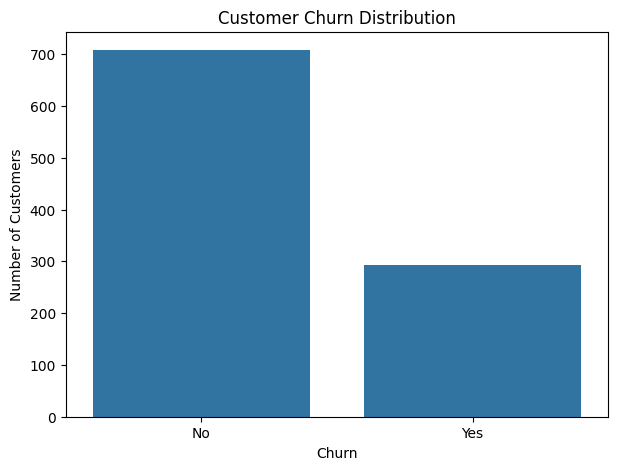

In [78]:
# ============================================
# VISUALISATION 1: CHURN DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

---

# Step 18 — Churn by Plan Type

In [79]:
# ============================================
# CHURN BY PLAN TYPE
# ============================================

plan_churn = pd.crosstab(
    df["Plan_Type"],
    df["Churn"],
    normalize="index"
) * 100

print(plan_churn)

Churn             No        Yes
Plan_Type                      
Postpaid   78.500000  21.500000
Prepaid    65.666667  34.333333


---

# Step 19 — Visualisation 2: Churn by Plan Type

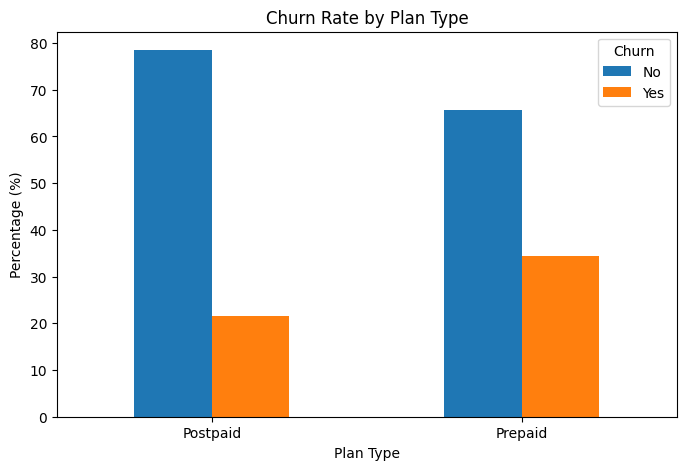

In [80]:
# ============================================
# VISUALISATION 2: CHURN BY PLAN TYPE
# ============================================

plan_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

---

# Step 20 — Churn by Contract Type

In [81]:
# ============================================
# CHURN BY CONTRACT TYPE
# ============================================

contract_churn = pd.crosstab(
    df["Contract_Type"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract_Type                       
Month-to-Month  68.358209  31.641791
One-Year        65.652174  34.347826
Two-Year        99.000000   1.000000


---

# Step 21 — Churn by Gender

In [82]:
# ============================================
# CHURN BY GENDER
# ============================================

gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)

Churn          No        Yes
Gender                      
Female  70.816327  29.183673
Male    70.784314  29.215686


---

# Step 22 — Churn by Tenure

Create tenure groups.

In [83]:
# ============================================
# STEP 22: CREATE TENURE GROUPS
# ============================================

df["Tenure_Group"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 12, 24, 48, 1000],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49+ Months"
    ]
)

print(df["Tenure_Group"].value_counts())

Tenure_Group
49+ Months      333
25-48 Months    333
0-12 Months     168
13-24 Months    166
Name: count, dtype: int64


---

# Step 23 — Churn by Tenure Group

In [84]:
# ============================================
# CHURN BY TENURE GROUP
# ============================================

tenure_churn = pd.crosstab(
    df["Tenure_Group"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn                No        Yes
Tenure_Group                      
0-12 Months   40.476190  59.523810
13-24 Months  60.240964  39.759036
25-48 Months  74.174174  25.825826
49+ Months    87.987988  12.012012


---

# Step 24 — High-Risk Customer Groups

In [85]:
# ============================================
# STEP 24: FIND HIGH-RISK CUSTOMER GROUPS
# ============================================

print("Churn rate by Plan:")
print(
    df.groupby("Plan_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("\nChurn rate by Contract:")
print(
    df.groupby("Contract_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("\nChurn rate by Tenure Group:")
print(
    df.groupby("Tenure_Group")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

Churn rate by Plan:
Plan_Type
Postpaid    21.500000
Prepaid     34.333333
Name: Churn, dtype: float64

Churn rate by Contract:
Contract_Type
Month-to-Month    31.641791
One-Year          34.347826
Two-Year           1.000000
Name: Churn, dtype: float64

Churn rate by Tenure Group:
Tenure_Group
0-12 Months     59.523810
13-24 Months    39.759036
25-48 Months    25.825826
49+ Months      12.012012
Name: Churn, dtype: float64


---

# Step 25 — High Recharge vs Churn

This directly answers:

> Do customers who recharge more stay loyal?

In [86]:
# ============================================
# STEP 25: RECHARGE VS CHURN
# ============================================

recharge_churn = df.groupby("Churn")[
    "Monthly_Recharge_INR"
].mean()

print("Average Monthly Recharge by Churn:")
print(recharge_churn)

Average Monthly Recharge by Churn:
Churn
No     697.587571
Yes    770.917808
Name: Monthly_Recharge_INR, dtype: float64


---

# Step 26 — Create Recharge Groups

In [87]:
# ============================================
# STEP 26: RECHARGE GROUPS
# ============================================

df["Recharge_Group"] = pd.qcut(
    df["Monthly_Recharge_INR"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

print(df["Recharge_Group"].value_counts())

Recharge_Group
Low            300
Medium-High    300
Medium-Low     200
High           200
Name: count, dtype: int64


---

# Step 27 — Churn by Recharge Group

In [88]:
# ============================================
# STEP 27: CHURN BY RECHARGE GROUP
# ============================================

recharge_group_churn = pd.crosstab(
    df["Recharge_Group"],
    df["Churn"],
    normalize="index"
) * 100

print(recharge_group_churn)

Churn                  No        Yes
Recharge_Group                      
Low             74.333333  25.666667
Medium-Low      75.000000  25.000000
Medium-High     70.000000  30.000000
High            62.500000  37.500000


---

# Step 28 — Visualisation 3: Recharge vs Churn

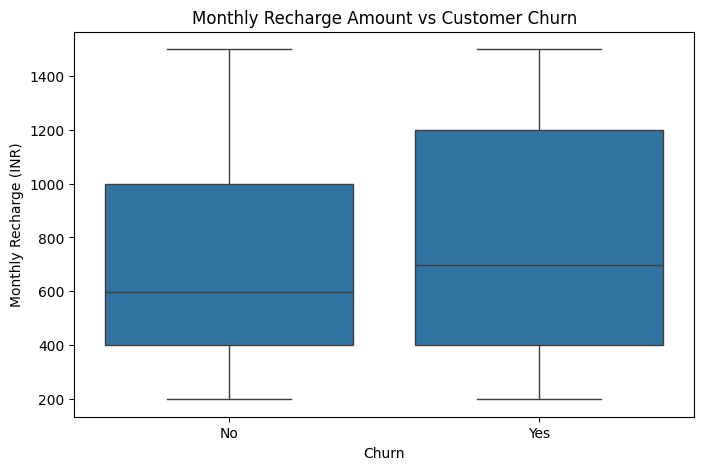

In [89]:
# ============================================
# VISUALISATION 3: RECHARGE VS CHURN
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Monthly_Recharge_INR"
)

plt.title("Monthly Recharge Amount vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Recharge (INR)")

plt.show()

---

# Step 29 — Complaints vs Churn

In [90]:
# ============================================
# STEP 29: COMPLAINTS VS CHURN
# ============================================

complaint_churn = df.groupby("Churn")[
    "Complaints_Logged"
].mean()

print("Average Complaints by Churn:")
print(complaint_churn)

Average Complaints by Churn:
Churn
No     0.426554
Yes    2.184932
Name: Complaints_Logged, dtype: float64


---

# Step 30 — Complaint Groups

In [91]:
# ============================================
# STEP 30: COMPLAINT GROUPS
# ============================================

df["Complaint_Group"] = pd.cut(
    df["Complaints_Logged"],
    bins=[-1, 0, 1, 2, 100],
    labels=[
        "No Complaints",
        "1 Complaint",
        "2 Complaints",
        "3+ Complaints"
    ]
)

print(df["Complaint_Group"].value_counts())

Complaint_Group
No Complaints    520
1 Complaint      240
2 Complaints     120
3+ Complaints    120
Name: count, dtype: int64


---

# Step 31 — Complaint Group Churn

In [92]:
# ============================================
# STEP 31: CHURN BY COMPLAINT GROUP
# ============================================

complaint_group_churn = pd.crosstab(
    df["Complaint_Group"],
    df["Churn"],
    normalize="index"
) * 100

print(complaint_group_churn)

Churn                   No        Yes
Complaint_Group                      
No Complaints    94.230769   5.769231
1 Complaint      64.583333  35.416667
2 Complaints     35.000000  65.000000
3+ Complaints    17.500000  82.500000


---

# Step 32 — Visualisation 4: Complaints vs Churn

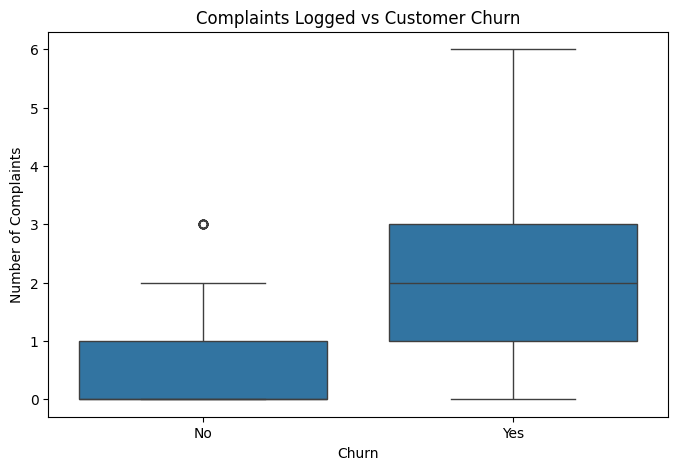

In [93]:
# ============================================
# VISUALISATION 4: COMPLAINTS VS CHURN
# ============================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Complaints_Logged"
)

plt.title("Complaints Logged vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Complaints")

plt.show()

---

# Step 33 — Service Usage Analysis

In [94]:
# ============================================
# STEP 33: SERVICE USAGE ANALYSIS
# ============================================

usage_analysis = df.groupby("Churn")[
    [
        "Data_Usage_GB",
        "Call_Duration_Minutes"
    ]
].mean()

print(usage_analysis)

       Data_Usage_GB  Call_Duration_Minutes
Churn                                      
No         44.518503             525.569209
Yes        40.965411             521.294521


---

# Step 34 — Usage and Complaints Together

In [95]:
# ============================================
# STEP 34: USAGE + COMPLAINTS
# ============================================

usage_complaint_analysis = df.groupby("Churn")[
    [
        "Data_Usage_GB",
        "Call_Duration_Minutes",
        "Complaints_Logged"
    ]
].mean()

usage_complaint_analysis

,Data_Usage_GB,Call_Duration_Minutes,Complaints_Logged
Churn,,,
No,44.518503,525.569209,0.426554
Yes,40.965411,521.294521,2.184932


---

# Step 35 — Correlation Analysis

In [96]:
# ============================================
# STEP 35: CORRELATION ANALYSIS
# ============================================

correlation_columns = [
    "Age",
    "Tenure_Months",
    "Monthly_Recharge_INR",
    "Data_Usage_GB",
    "Call_Duration_Minutes",
    "Complaints_Logged"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Age,Tenure_Months,Monthly_Recharge_INR,Data_Usage_GB,Call_Duration_Minutes,Complaints_Logged
Age,1.000000,-0.003280,0.002022,0.004549,-0.006190,0.001484
Tenure_Months,-0.003280,1.000000,-0.016654,-0.002559,-0.014670,0.002976
Monthly_Recharge_INR,0.002022,-0.016654,1.000000,0.006081,-0.010048,-0.003506
Data_Usage_GB,0.004549,-0.002559,0.006081,1.000000,0.021286,-0.007207
Call_Duration_Minutes,-0.006190,-0.014670,-0.010048,0.021286,1.000000,-0.025630
Complaints_Logged,0.001484,0.002976,-0.003506,-0.007207,-0.025630,1.000000


---

# Step 36 — Correlation Heatmap

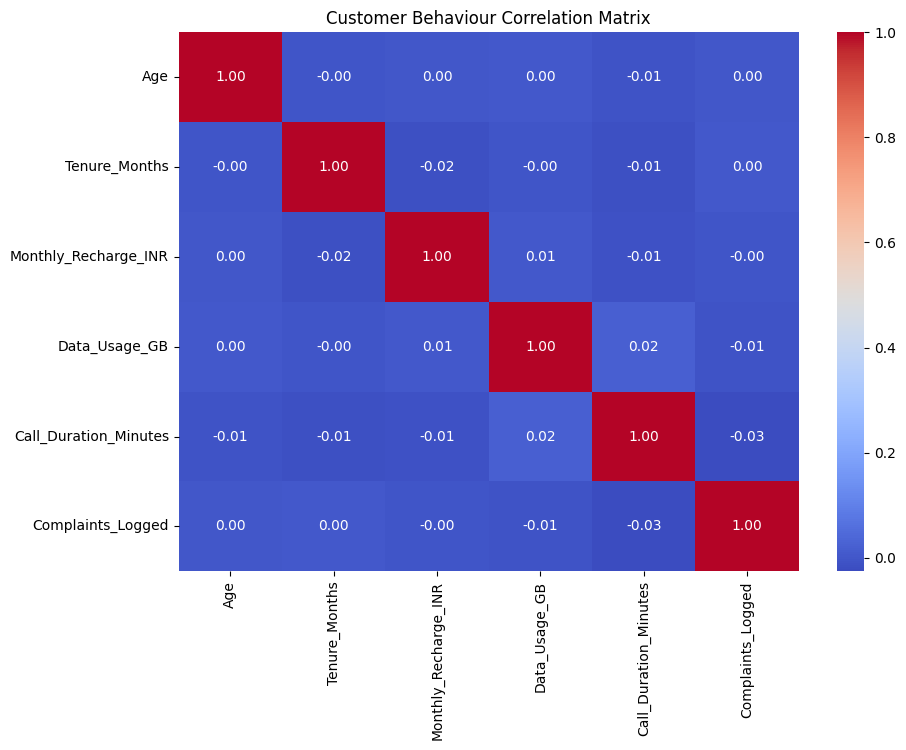

In [97]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Behaviour Correlation Matrix")

plt.show()

This is an **additional analysis chart**. Your main expected output still has the four visualisations above.

---

# Step 37 — Typical High-Risk Customer

Now identify characteristics of customers who churned.

In [98]:
# ============================================
# STEP 37: HIGH-RISK CUSTOMER PROFILE
# ============================================

churned_customers = df[df["Churn"] == "Yes"]

high_risk_profile = {
    "Average Age": churned_customers["Age"].mean(),
    "Average Tenure": churned_customers["Tenure_Months"].mean(),
    "Average Recharge": churned_customers["Monthly_Recharge_INR"].mean(),
    "Average Data Usage": churned_customers["Data_Usage_GB"].mean(),
    "Average Call Minutes": churned_customers["Call_Duration_Minutes"].mean(),
    "Average Complaints": churned_customers["Complaints_Logged"].mean()
}

high_risk_profile

{'Average Age': np.float64(43.43493150684932),
 'Average Tenure': np.float64(24.96917808219178),
 'Average Recharge': np.float64(770.917808219178),
 'Average Data Usage': np.float64(40.96541095890411),
 'Average Call Minutes': np.float64(521.2945205479452),
 'Average Complaints': np.float64(2.184931506849315)}

---

# Step 38 — Most Common High-Risk Categories

In [99]:
# ============================================
# STEP 38: HIGH-RISK CUSTOMER CHARACTERISTICS
# ============================================

print("Most common gender among churned customers:")
print(churned_customers["Gender"].value_counts())

print("\nMost common plan among churned customers:")
print(churned_customers["Plan_Type"].value_counts())

print("\nMost common contract among churned customers:")
print(churned_customers["Contract_Type"].value_counts())

print("\nMost common payment method:")
print(churned_customers["Payment_Method"].value_counts())

Most common gender among churned customers:
Gender
Male      149
Female    143
Name: count, dtype: int64

Most common plan among churned customers:
Plan_Type
Prepaid     206
Postpaid     86
Name: count, dtype: int64

Most common contract among churned customers:
Contract_Type
Month-to-Month    212
One-Year           79
Two-Year            1
Name: count, dtype: int64

Most common payment method:
Payment_Method
UPI            114
Credit Card     56
Debit Card      51
Net Banking     42
Wallet          29
Name: count, dtype: int64


---

# Step 39 — Prepare Dataset for Machine Learning

Now we start the **Random Forest** section.

In [100]:
# ============================================
# STEP 39: PREPARE DATA FOR MACHINE LEARNING
# ============================================

ml_df = df.copy()

# Remove columns that are not useful for prediction
ml_df = ml_df.drop(
    columns=[
        "Customer_ID",
        "Tenure_Group",
        "Recharge_Group",
        "Complaint_Group"
    ],
    errors="ignore"
)

print(ml_df.columns.tolist())

['Gender', 'Age', 'Tenure_Months', 'Plan_Type', 'Contract_Type', 'Monthly_Recharge_INR', 'Data_Usage_GB', 'Call_Duration_Minutes', 'Complaints_Logged', 'Payment_Method', 'Churn']


---

# Step 40 — Encode Target

In [101]:
# ============================================
# STEP 40: ENCODE TARGET VARIABLE
# ============================================

ml_df["Churn"] = ml_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(ml_df["Churn"].value_counts())

Churn
0    708
1    292
Name: count, dtype: int64


---

# Step 41 — Encode Categorical Features

In [102]:
# ============================================
# STEP 41: ENCODE CATEGORICAL FEATURES
# ============================================

categorical_columns = [
    "Gender",
    "Plan_Type",
    "Contract_Type",
    "Payment_Method"
]

label_encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    ml_df[col] = encoder.fit_transform(ml_df[col])
    label_encoders[col] = encoder

print("Categorical columns encoded successfully!")

ml_df.head()

Categorical columns encoded successfully!


,Gender,Age,Tenure_Months,Plan_Type,Contract_Type,Monthly_Recharge_INR,Data_Usage_GB,Call_Duration_Minutes,Complaints_Logged,Payment_Method,Churn
0,0,68,43,1,0,1199,11.2,162.0,0,3,0
1,1,58,72,1,0,1499,18.5,251.0,0,0,0
2,0,48,29,0,0,199,25.8,340.0,0,3,0
3,1,38,58,0,1,299,33.1,429.0,0,1,0
4,1,28,15,1,0,399,40.4,518.0,0,2,1


---

# Step 42 — Separate Features and Target

In [103]:
# ============================================
# STEP 42: X AND Y
# ============================================

X = ml_df.drop("Churn", axis=1)

y = ml_df["Churn"]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

Feature columns:
['Gender', 'Age', 'Tenure_Months', 'Plan_Type', 'Contract_Type', 'Monthly_Recharge_INR', 'Data_Usage_GB', 'Call_Duration_Minutes', 'Complaints_Logged', 'Payment_Method']

Target column:
Churn


---

# Step 43 — Train-Test Split

In [104]:
# ============================================
# STEP 43: TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 10)
Testing data: (200, 10)


---

# Step 44 — Create Random Forest

In [105]:
# ============================================
# STEP 44: RANDOM FOREST MODEL
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

print("Random Forest model created!")

Random Forest model created!


---

# Step 45 — Train Model

In [106]:
# ============================================
# STEP 45: TRAIN RANDOM FOREST
# ============================================

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


---

# Step 46 — Make Predictions

In [107]:
# ============================================
# STEP 46: PREDICTIONS
# ============================================

y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0]


---

# Step 47 — Model Accuracy

In [108]:
# ============================================
# STEP 47: ACCURACY
# ============================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 88.5 %


---

# Step 48 — Precision, Recall and F1

In [109]:
# ============================================
# STEP 48: MODEL EVALUATION
# ============================================

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Accuracy : 0.885
Precision: 0.807
Recall   : 0.793
F1 Score : 0.8


---

# Step 49 — Classification Report

In [110]:
# ============================================
# STEP 49: CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Not Churn       0.92      0.92      0.92       142
       Churn       0.81      0.79      0.80        58

    accuracy                           0.89       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.88      0.89      0.88       200



---

# Step 50 — Confusion Matrix

In [111]:
# ============================================
# STEP 50: CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[131  11]
 [ 12  46]]


---

# Step 51 — Confusion Matrix Visualisation

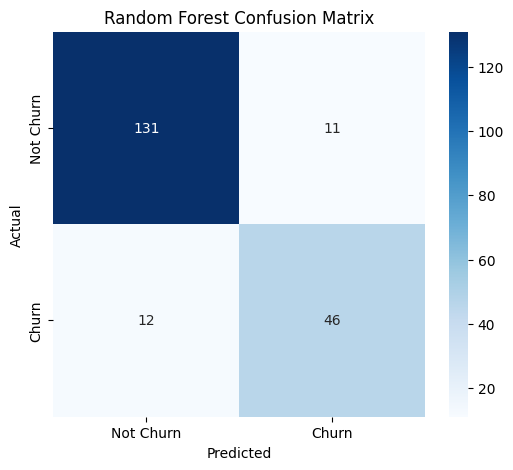

In [112]:
# ============================================
# CONFUSION MATRIX VISUALIZATION
# ============================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

---

# Step 52 — Feature Importance

This is very useful for explaining **why the model predicts churn**.

In [113]:
# ============================================
# STEP 52: FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,Complaints_Logged,0.375970
2,Tenure_Months,0.250170
6,Data_Usage_GB,0.078138
5,Monthly_Recharge_INR,0.061393
1,Age,0.060222
7,Call_Duration_Minutes,0.058909
4,Contract_Type,0.053812
9,Payment_Method,0.030230
3,Plan_Type,0.018767
0,Gender,0.012390


---

# Step 53 — Feature Importance Graph

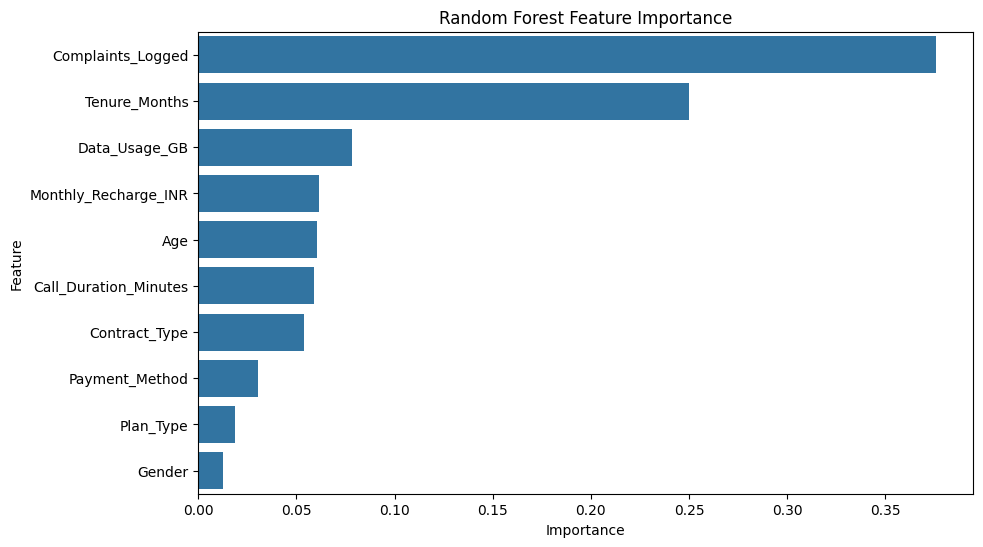

In [114]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

---

# Step 54 — Final 5–7 Key Insights

Run this to generate useful numerical information for your report.

In [115]:
# ============================================
# STEP 54: KEY INSIGHTS
# ============================================

overall_churn = (
    df["Churn"].value_counts(normalize=True)["Yes"] * 100
)

avg_recharge_churn = df[
    df["Churn"] == "Yes"
]["Monthly_Recharge_INR"].mean()

avg_recharge_no_churn = df[
    df["Churn"] == "No"
]["Monthly_Recharge_INR"].mean()

avg_complaints_churn = df[
    df["Churn"] == "Yes"
]["Complaints_Logged"].mean()

avg_complaints_no_churn = df[
    df["Churn"] == "No"
]["Complaints_Logged"].mean()

avg_tenure_churn = df[
    df["Churn"] == "Yes"
]["Tenure_Months"].mean()

avg_tenure_no_churn = df[
    df["Churn"] == "No"
]["Tenure_Months"].mean()

print("========== KEY INSIGHTS ==========\n")

print(
    f"1. Overall churn rate is {overall_churn:.2f}%."
)

print(
    f"2. Average monthly recharge of churned customers is "
    f"₹{avg_recharge_churn:.2f}, compared with "
    f"₹{avg_recharge_no_churn:.2f} for non-churned customers."
)

print(
    f"3. Churned customers have an average of "
    f"{avg_complaints_churn:.2f} complaints, compared with "
    f"{avg_complaints_no_churn:.2f} for non-churned customers."
)

print(
    f"4. Average tenure of churned customers is "
    f"{avg_tenure_churn:.2f} months, compared with "
    f"{avg_tenure_no_churn:.2f} months for non-churned customers."
)

highest_plan = (
    df.groupby("Plan_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .idxmax()
)

highest_plan_rate = (
    df.groupby("Plan_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .max()
)

print(
    f"5. The plan type with the highest observed churn rate is "
    f"{highest_plan} at {highest_plan_rate:.2f}%."
)

highest_contract = (
    df.groupby("Contract_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .idxmax()
)

highest_contract_rate = (
    df.groupby("Contract_Type")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .max()
)

print(
    f"6. The contract type with the highest observed churn rate is "
    f"{highest_contract} at {highest_contract_rate:.2f}%."
)

top_feature = feature_importance.iloc[0]["Feature"]

print(
    f"7. The Random Forest model identifies {top_feature} "
    f"as the most important feature among the supplied variables."
)

========== KEY INSIGHTS ==========

1. Overall churn rate is 29.20%.
2. Average monthly recharge of churned customers is ₹770.92, compared with ₹697.59 for non-churned customers.
3. Churned customers have an average of 2.18 complaints, compared with 0.43 for non-churned customers.
4. Average tenure of churned customers is 24.97 months, compared with 41.23 months for non-churned customers.
5. The plan type with the highest observed churn rate is Prepaid at 34.33%.
6. The contract type with the highest observed churn rate is One-Year at 34.35%.
7. The Random Forest model identifies Complaints_Logged as the most important feature among the supplied variables.


---

# Step 55 — Practical Action Plan

In [116]:
# ============================================
# STEP 55: BUSINESS ACTION PLAN
# ============================================

print("""
========== PRACTICAL ACTION PLAN ==========

1. Complaint Reduction:
   Identify customers with repeated complaints and provide
   faster customer support, issue resolution and proactive
   service follow-up.

2. High-Risk Customer Retention:
   Use the Random Forest model to identify customers with
   characteristics associated with higher churn and provide
   suitable retention offers or service support.

3. Contract and Plan Optimization:
   Analyse plans and contract types with higher observed churn
   and review their pricing, benefits, service quality and
   customer experience.
""")


========== PRACTICAL ACTION PLAN ==========

1. Complaint Reduction:
   Identify customers with repeated complaints and provide
   faster customer support, issue resolution and proactive
   service follow-up.

2. High-Risk Customer Retention:
   Use the Random Forest model to identify customers with
   characteristics associated with higher churn and provide
   suitable retention offers or service support.

3. Contract and Plan Optimization:
   Analyse plans and contract types with higher observed churn
   and review their pricing, benefits, service quality and
   customer experience.



---

# Step 56 — Save the Trained Model

If your assignment requires the model file:

In [117]:
# ============================================
# STEP 56: SAVE RANDOM FOREST MODEL
# ============================================

import joblib

joblib.dump(
    rf_model,
    "customer_churn_random_forest.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "customer_churn_features.pkl"
)

print("Model saved successfully!")

Model saved successfully!


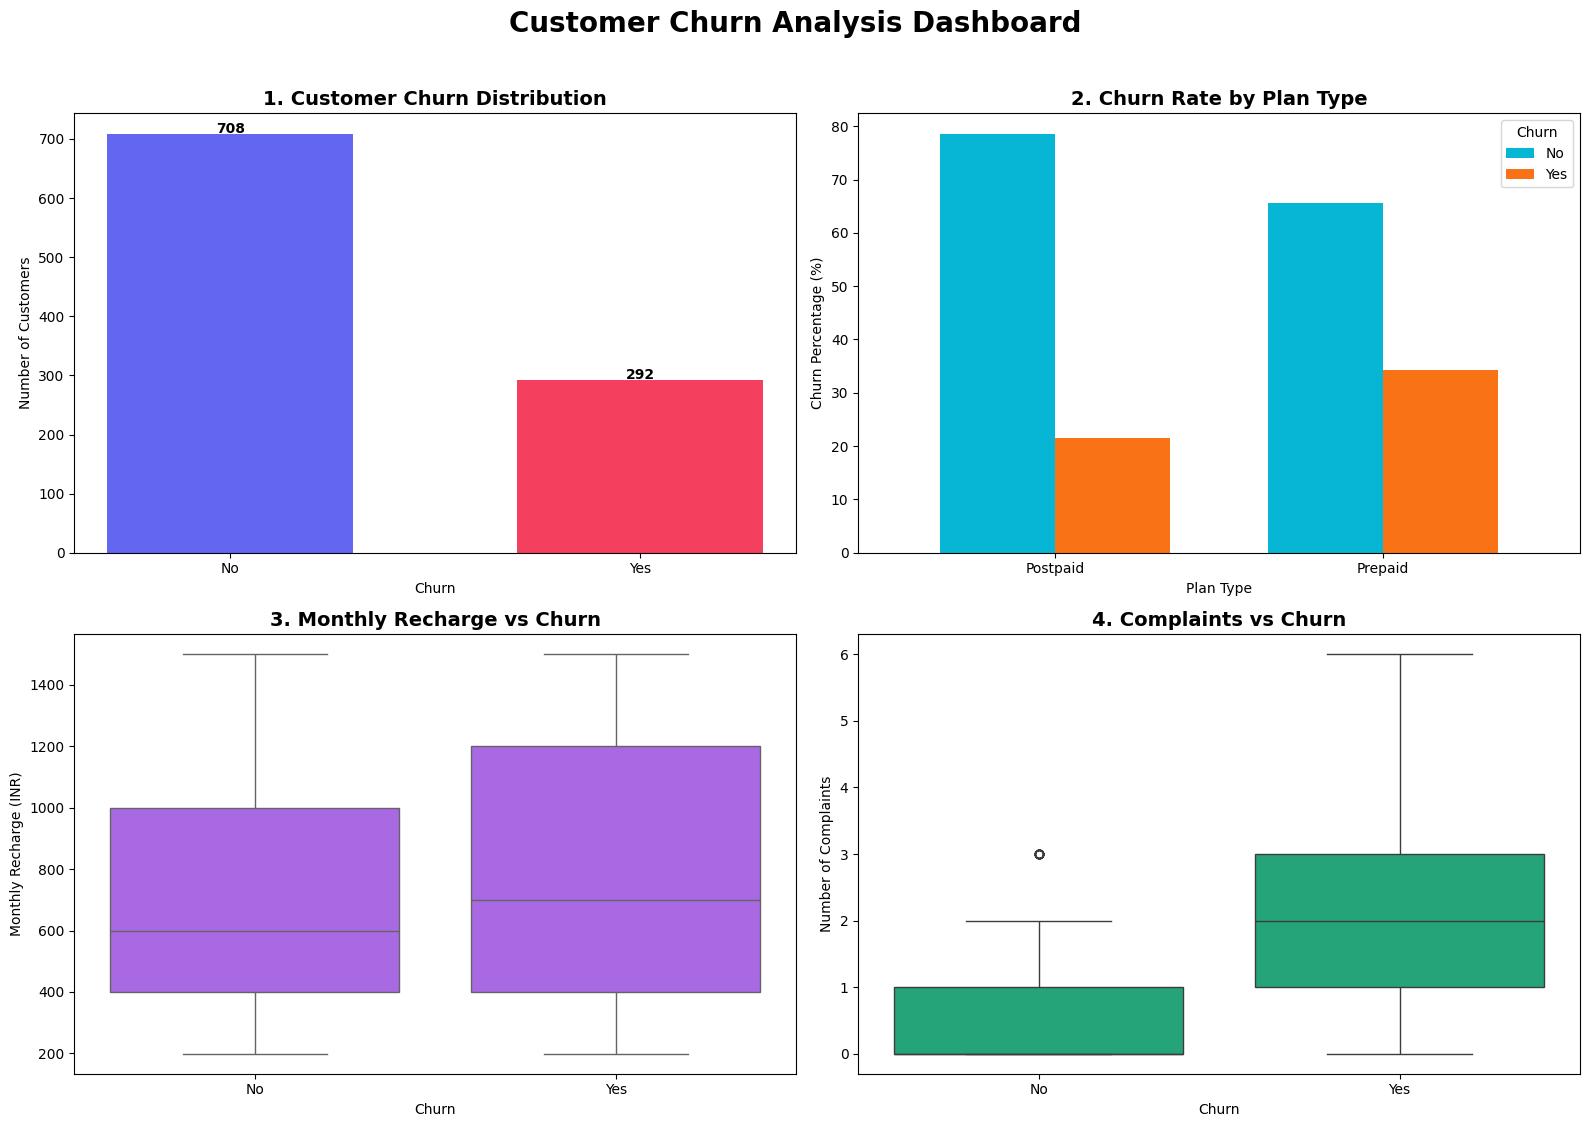

In [118]:
# ============================================================
# 4 CHARTS IN 2 x 2 GRID
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ============================================================
# CHART 1: CUSTOMER CHURN DISTRIBUTION
# ============================================================

churn_counts = df["Churn"].value_counts()

axes[0, 0].bar(
    churn_counts.index,
    churn_counts.values,
    color=["#6366F1", "#F43F5E"],
    width=0.6
)

axes[0, 0].set_title(
    "1. Customer Churn Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    axes[0, 0].text(
        i,
        value + 2,
        str(value),
        ha="center",
        fontweight="bold"
    )


# ============================================================
# CHART 2: CHURN BY PLAN TYPE
# ============================================================

plan_churn = pd.crosstab(
    df["Plan_Type"],
    df["Churn"],
    normalize="index"
) * 100

plan_churn.plot(
    kind="bar",
    ax=axes[0, 1],
    color=["#06B6D4", "#F97316"],
    width=0.7
)

axes[0, 1].set_title(
    "2. Churn Rate by Plan Type",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Plan Type")
axes[0, 1].set_ylabel("Churn Percentage (%)")
axes[0, 1].tick_params(axis="x", rotation=0)

axes[0, 1].legend(
    title="Churn",
    loc="upper right"
)


# ============================================================
# CHART 3: MONTHLY RECHARGE VS CHURN
# ============================================================

sns.boxplot(
    data=df,
    x="Churn",
    y="Monthly_Recharge_INR",
    ax=axes[1, 0],
    color="#A855F7"
)

axes[1, 0].set_title(
    "3. Monthly Recharge vs Churn",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Churn")
axes[1, 0].set_ylabel("Monthly Recharge (INR)")


# ============================================================
# CHART 4: COMPLAINTS VS CHURN
# ============================================================

sns.boxplot(
    data=df,
    x="Churn",
    y="Complaints_Logged",
    ax=axes[1, 1],
    color="#10B981"
)

axes[1, 1].set_title(
    "4. Complaints vs Churn",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Churn")
axes[1, 1].set_ylabel("Number of Complaints")


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.suptitle(
    "Customer Churn Analysis Dashboard",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()